# 1. Dataset Analysis

## 1.1 Load Dataset

In [1]:
import pandas as pd
dataset_path = "/kaggle/input/resume-dataset/Resume/Resume.csv"
df = pd.read_csv(dataset_path)
print(df)

            ID                                         Resume_str  \
0     16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1     22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2     33176873           HR DIRECTOR       Summary      Over 2...   
3     27018550           HR SPECIALIST       Summary    Dedica...   
4     17812897           HR MANAGER         Skill Highlights  ...   
...        ...                                                ...   
2479  99416532           RANK: SGT/E-5 NON- COMMISSIONED OFFIC...   
2480  24589765           GOVERNMENT RELATIONS, COMMUNICATIONS ...   
2481  31605080           GEEK SQUAD AGENT         Professional...   
2482  21190805           PROGRAM DIRECTOR / OFFICE MANAGER    ...   
2483  37473139           STOREKEEPER II       Professional Sum...   

                                            Resume_html  Category  
0     <div class="fontsize fontface vmargins hmargin...        HR  
1     <div class="fontsize fontface

# 1.2 Analyse data distribution

Categories: HR, DESIGNER, INFORMATION-TECHNOLOGY, TEACHER, ADVOCATE, BUSINESS-DEVELOPMENT, HEALTHCARE, FITNESS, AGRICULTURE, BPO, SALES, CONSULTANT, DIGITAL-MEDIA, AUTOMOBILE, CHEF, FINANCE, APPAREL, ENGINEERING, ACCOUNTANT, CONSTRUCTION, PUBLIC-RELATIONS, BANKING, ARTS, AVIATION
                  category  items
0                       HR    110
1                 DESIGNER    107
2   INFORMATION-TECHNOLOGY    120
3                  TEACHER    102
4                 ADVOCATE    118
5     BUSINESS-DEVELOPMENT    120
6               HEALTHCARE    115
7                  FITNESS    117
8              AGRICULTURE     63
9                      BPO     22
10                   SALES    116
11              CONSULTANT    115
12           DIGITAL-MEDIA     96
13              AUTOMOBILE     36
14                    CHEF    118
15                 FINANCE    118
16                 APPAREL     97
17             ENGINEERING    118
18              ACCOUNTANT    118
19            CONSTRUCTION    112
20   

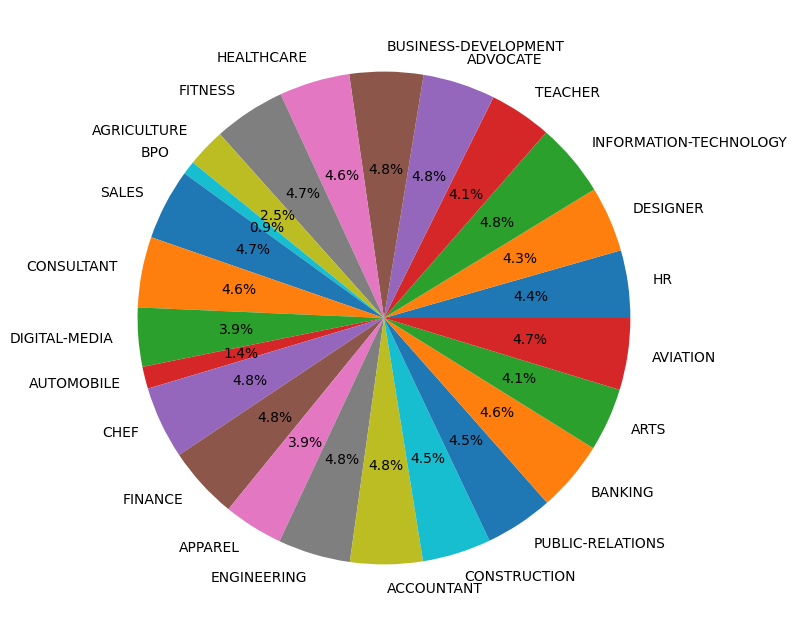

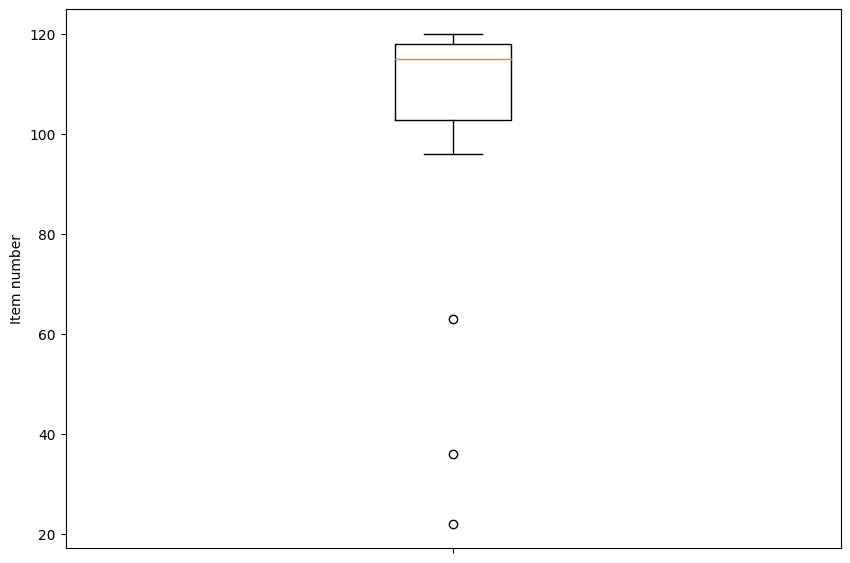

In [2]:
import matplotlib.pyplot as plt

# Save as a function to reuse it later
def get_stats(d):
    categories = d["Category"].unique()
    print("Categories: {}".format(", ".join(categories)))
    stats = [] # Can be used later for even more information
    avg = 0
    for label in categories:
        subset = d[d["Category"] == label]
        stats.append({
            "category": label,
            "items": len(subset)
        })
        avg += len(subset)
    avg /= len(stats)
    stats_df = pd.DataFrame(stats)
    print(stats_df)
    print("Average: {} items".format(avg))
    fig, ax = plt.subplots(figsize=(12,8))
    ax.pie(stats_df["items"], labels=stats_df["category"], autopct='%1.1f%%')
    plt.show()
    fig = plt.figure(figsize =(10, 7))
    plt.boxplot(stats_df["items"])
    plt.ylabel("Item number")
    plt.xticks([1], [""])
    plt.show()
    return stats
# Get dataset statistics
stats = get_stats(df)

## 1.3 Outliers

There are 3 apparent outliers.

| |category|item|
|---|---|---|
|8  |           AGRICULTURE     |63|
|9  |                   BPO     |22|
|13 |             AUTOMOBILE    |36|

1. BPO - Business process outsourcing, is an area of management, so it can be merged with BUSINESS-DEVELOPMENT category.
2. BUSINESS-DEVELOPMENT, BPO is too big now, so it can be downsampled by randomly removing 20 samples from the original BUSINESS-DEVELOPMENT category.
3. There is not enough data about AUTOMOBILE and AGRICULTURE categories. Upsampling them may lead to performance degradation. Downsampling the rest of the dataset is not rational. This category should be removed.

            ID                                         Resume_str  \
0     16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1     22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2     33176873           HR DIRECTOR       Summary      Over 2...   
3     27018550           HR SPECIALIST       Summary    Dedica...   
4     17812897           HR MANAGER         Skill Highlights  ...   
...        ...                                                ...   
2460  54246169           AGRICULTURE ADVISOR AND LANGUAGE OFFI...   
2461  12341902           EDUCATION OFFICER & SENIOR EDUCATION ...   
2462  29510501           LEAD TEACHER       Professional Summa...   
2463  10953078           RN STAFF NURSE                 Profes...   
2464  23631188           ACCOUNTS PAYABLE AP - (CREDITORS) SUP...   

                                            Resume_html     Category  
0     <div class="fontsize fontface vmargins hmargin...           HR  
1     <div class="fontsize fo

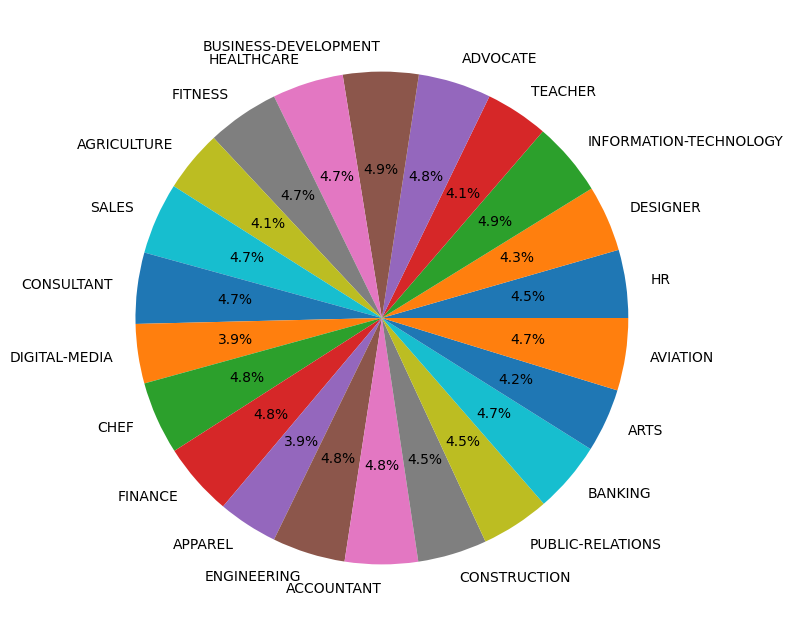

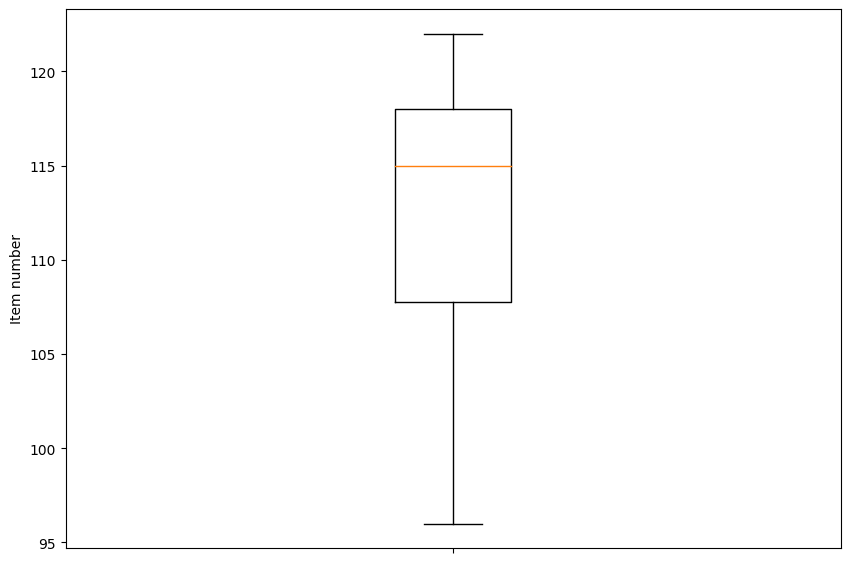

In [3]:
# Get 20 random BUSINESS-DEVELOPMENT samples and remove them from the dataset
bd = df[df["Category"] == "BUSINESS-DEVELOPMENT"].sample(20)
df = df.drop(bd.index)
# Set category on BPO to BUSINESS-DEVELOPMENT
df.loc[df['Category'] == "BPO", "Category"] = "BUSINESS-DEVELOPMENT"
# Remove automobile and agriculture categories
df = df[df["Category"] != "AUTOMOBILE"]
# Upsample AGRICULTURE category
new_samples = df[df["Category"] == "AGRICULTURE"].sample(37)
df_showcase = pd.concat([df, new_samples], ignore_index = True)
df_showcase = df_showcase.reset_index(drop=True)
print(df_showcase)
df = df.reset_index(drop=True)
stats = get_stats(df_showcase)

 Mostly even data distribution with no apparent outliers

# 2. Tokenization

Define parameters:

In [4]:
MODEL = "distilbert-base-uncased"

## 2.1 Load Tokenizer

In [5]:
import torch
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## 2.2 Analyze tokenized dataset

Token indices sequence length is longer than the specified maximum sequence length for this model (835 > 512). Running this sequence through the model will result in indexing errors


Tokenizing text 0/2428...
Tokenizing text 200/2428...
Tokenizing text 400/2428...
Tokenizing text 600/2428...
Tokenizing text 800/2428...
Tokenizing text 1000/2428...
Tokenizing text 1200/2428...
Tokenizing text 1400/2428...
Tokenizing text 1600/2428...
Tokenizing text 1800/2428...
Tokenizing text 2000/2428...
Tokenizing text 2200/2428...
Tokenizing text 2400/2428...
                  category  items  max_tokens  min_tokens   avg_tokens
0                       HR    110        4252         304  1102.581818
1                 DESIGNER    107        3073         143   961.775701
2   INFORMATION-TECHNOLOGY    120        3960         314  1252.991667
3                  TEACHER    102        3051         213   896.656863
4                 ADVOCATE    118        4581         322  1082.152542
5     BUSINESS-DEVELOPMENT    122        2763           2  1049.040984
6               HEALTHCARE    115        3476         306  1140.678261
7                  FITNESS    117        2299         241   90

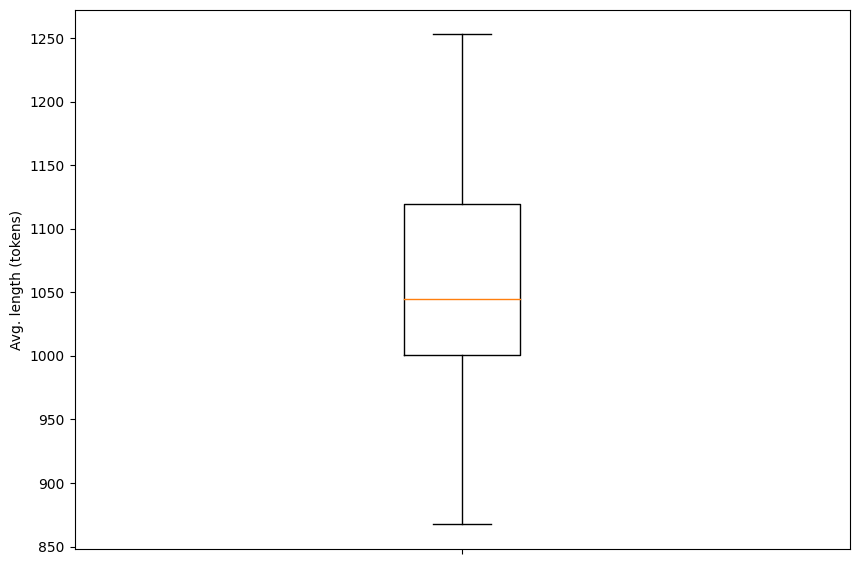

In [6]:
num_tokens = []
for index, row in df.iterrows():
    if index % 200 == 0:
        print("Tokenizing text {}/{}...".format(index, len(df)))
    tokens = tokenizer(row["Resume_str"])
    num_tokens.append(len(tokens[0]))
df.insert(1,"num_tokens", num_tokens, True)
for item in stats:
    data = df[df["Category"] == item["category"]]
    item["max_tokens"] = data["num_tokens"].max()
    item["min_tokens"] = data["num_tokens"].min()
    item["avg_tokens"] = data["num_tokens"].mean()
stats_df = pd.DataFrame(stats)
print(stats_df)
print("Average avg_tokens: {}".format(stats_df["avg_tokens"].mean()))
fig = plt.figure(figsize =(10, 7))
plt.boxplot(stats_df["avg_tokens"])
plt.ylabel("Avg. length (tokens)")
plt.xticks([1], [""])
plt.show()

The length of resume texts seems to have quite big range, but without any obvious outliers

## 2.3 Convert labels to strings

In [7]:
label_texts = []
for i, label in enumerate(df["Category"].unique()):
    label_texts.append(label)
print(label_texts)

['HR', 'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE', 'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT', 'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION']


## 2.4 Tokenize Again with Truncation and Padding

In [8]:
encodings = []
for index, row in df.iterrows():
    if index % 200 == 0:
        print("Tokenizing text {}/{}...".format(index, len(df)))
    tokens = tokenizer(row["Resume_str"], padding="max_length", truncation=True, max_length=512)
    label = label_texts.index(row["Category"])
    tokens["label"] = label
    encodings.append(tokens)
processed_data = pd.DataFrame(encodings)
print(processed_data)

Tokenizing text 0/2428...
Tokenizing text 200/2428...
Tokenizing text 400/2428...
Tokenizing text 600/2428...
Tokenizing text 800/2428...
Tokenizing text 1000/2428...
Tokenizing text 1200/2428...
Tokenizing text 1400/2428...
Tokenizing text 1600/2428...
Tokenizing text 1800/2428...
Tokenizing text 2000/2428...
Tokenizing text 2200/2428...
Tokenizing text 2400/2428...
                                         attention_mask  \
0     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
1     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
2     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
3     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
4     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
...                                                 ...   
2423  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
2424  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
2425  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
2426  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

# 2.5 Shuffle dataset

In [9]:
processed_data = processed_data.sample(frac=1).reset_index(drop=True)
print(processed_data)

                                         attention_mask  \
0     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
1     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
2     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
3     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
4     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
...                                                 ...   
2423  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
2424  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
2425  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
2426  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
2427  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   

                                              input_ids  label  
0     [101, 17850, 7904, 4262, 8325, 12654, 4056, 19...      0  
1     [101, 3935, 2504, 17320, 4316, 15893, 2476, 35...     21  
2     [101, 3136, 3208, 2658, 12654, 6581, 2051, 296...      6  
3     [101, 17907, 12654, 2065,

## 2.6 Save processed dataset

In [10]:
import json
processed_data.to_parquet("dataset.parquet")
with open("labels.json", "w") as f:
    f.write(json.dumps(label_texts))
print("Processed dataset was saved to 'dataset.parquet' and 'labels.json'!")

Processed dataset was saved to 'dataset.parquet' and 'labels.json'!


# 3. Training

## 3.1 Load and shuffle dataset

In [11]:
DATASET = "dataset.parquet"
LABELS = "labels.json"

import json
import pandas as pd
df = pd.read_parquet(DATASET)
print(df)
labels = []
with open(LABELS, "r") as f:
    labels = json.loads(f.read())
print(labels)

                                         attention_mask  \
0     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
1     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
2     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
3     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
4     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
...                                                 ...   
2423  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
2424  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
2425  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
2426  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
2427  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   

                                              input_ids  label  
0     [101, 17850, 7904, 4262, 8325, 12654, 4056, 19...      0  
1     [101, 3935, 2504, 17320, 4316, 15893, 2476, 35...     21  
2     [101, 3136, 3208, 2658, 12654, 6581, 2051, 296...      6  
3     [101, 17907, 12654, 2065,

## 3.2 Split dataset for K-fold cross validation

In [12]:
K = 5


subsets = []
for i in range(K):
    step = round(len(df)/K)
    start_index = i*step
    end_index = (i+1)*step if i < K - 1 else len(df)
    subset = df[start_index:end_index]
    subsets.append(subset)
    print("Subset {} with a size of {}.".format(i+1, len(subset)))

Subset 1 with a size of 486.
Subset 2 with a size of 486.
Subset 3 with a size of 486.
Subset 4 with a size of 486.
Subset 5 with a size of 484.


## 3.3 Train/Test loop

2026-07-24 17:38:31.430868: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-24 17:38:31.431018: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-24 17:38:31.582558: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Runing experiment 1/5...



model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/conda/lib/python3.10/site-packages/accelerate/accelerator.py:436: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input ten

Epoch,Training Loss,Validation Loss
1,2.359600,1.271304
2,0.981400,0.787501
3,0.626300,0.701974


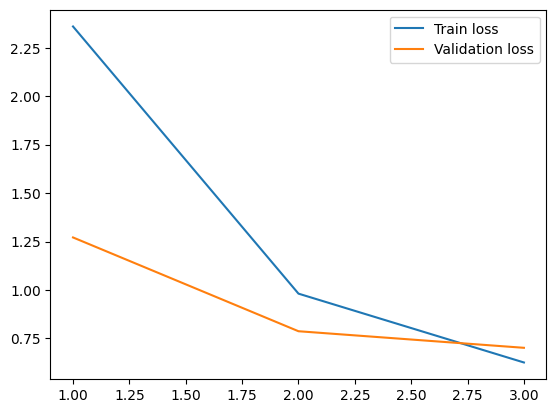

   Run  Precision    Recall   F-score  Accuracy  Train Loss  Validation Loss
0    1   0.861328  0.854251  0.852851  0.854251      0.6263         0.701974


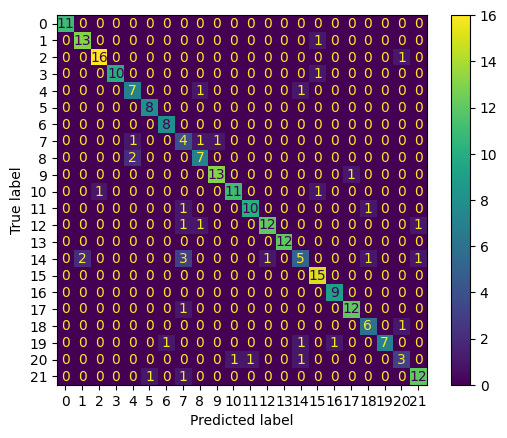

Runing experiment 2/5...



Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/conda/lib/python3.10/site-packages/accelerate/accelerator.py:436: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input ten

Epoch,Training Loss,Validation Loss
1,2.399900,1.345410
2,0.961600,0.776431
3,0.603200,0.712911


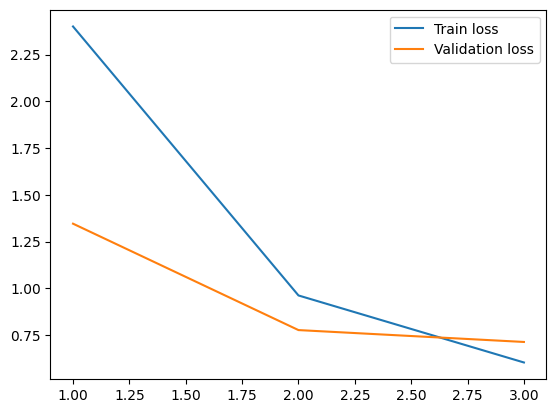

   Run  Precision    Recall   F-score  Accuracy  Train Loss  Validation Loss
0    2   0.886221  0.874494  0.872613  0.874494      0.6032         0.712911


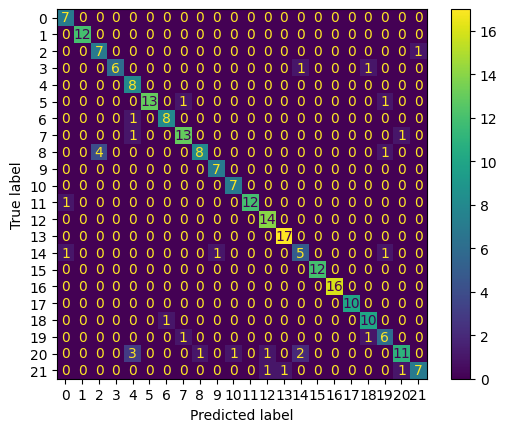

Runing experiment 3/5...



Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/conda/lib/python3.10/site-packages/accelerate/accelerator.py:436: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input ten

Epoch,Training Loss,Validation Loss
1,2.451600,1.395076
2,0.981400,0.759742
3,0.611400,0.690267


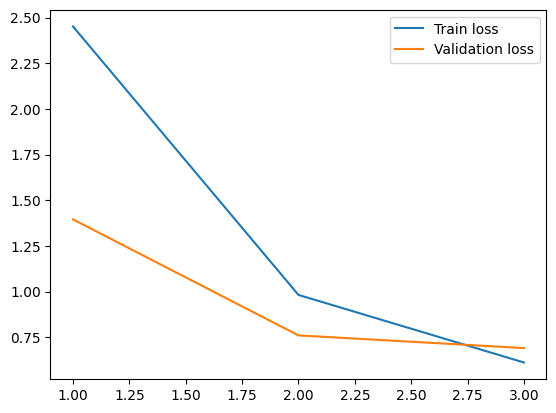

   Run  Precision    Recall   F-score  Accuracy  Train Loss  Validation Loss
0    3   0.847125  0.834008  0.832731  0.834008      0.6114         0.690267


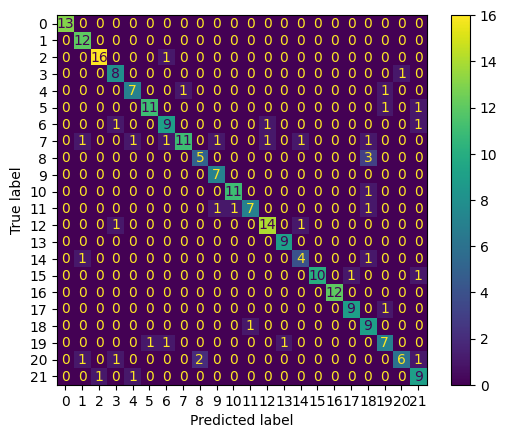

Runing experiment 4/5...



Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/conda/lib/python3.10/site-packages/accelerate/accelerator.py:436: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input ten

Epoch,Training Loss,Validation Loss
1,2.245200,1.110558
2,0.903100,0.668140
3,0.575900,0.581148


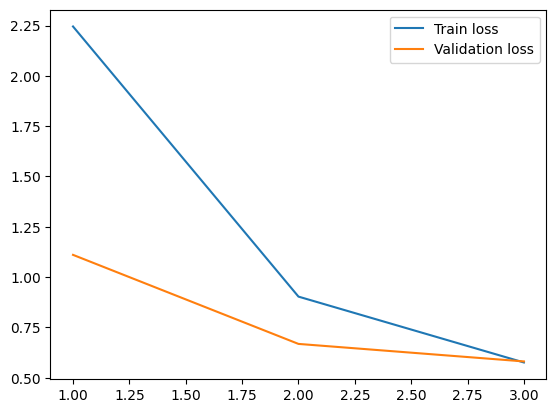

   Run  Precision    Recall   F-score  Accuracy  Train Loss  Validation Loss
0    4   0.841533  0.834008  0.830325  0.834008      0.5759         0.581148


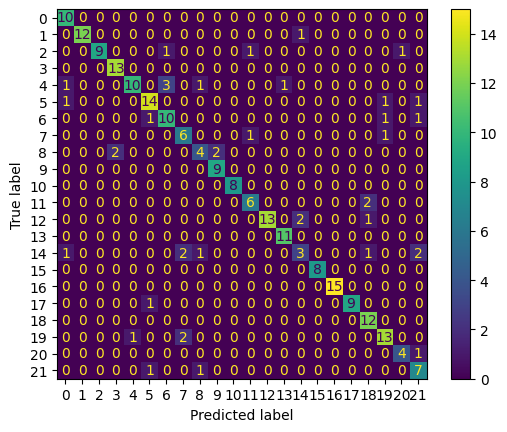

Runing experiment 5/5...



Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/conda/lib/python3.10/site-packages/accelerate/accelerator.py:436: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input ten

Epoch,Training Loss,Validation Loss
1,2.342900,1.383936
2,0.899600,0.865573
3,0.544200,0.778051


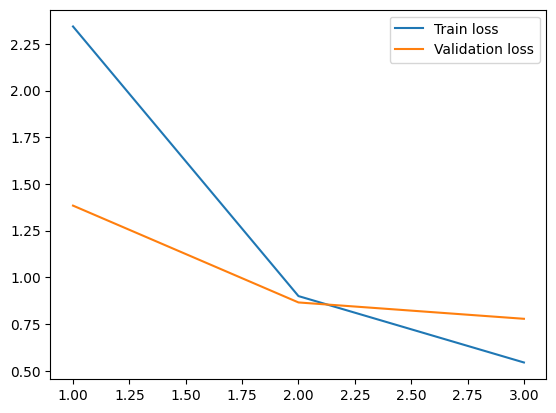

   Run  Precision    Recall   F-score  Accuracy  Train Loss  Validation Loss
0    5   0.832414  0.825203  0.818356  0.825203      0.5442         0.778051


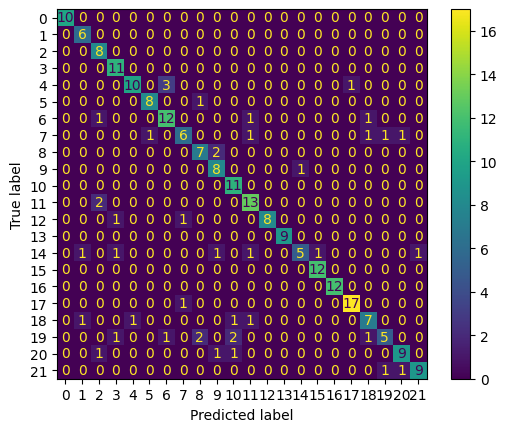

       Run  Precision    Recall   F-score  Accuracy  Train Loss  \
0        1   0.861328  0.854251  0.852851  0.854251      0.6263   
1        2   0.886221  0.874494  0.872613  0.874494      0.6032   
2        3   0.847125  0.834008  0.832731  0.834008      0.6114   
3        4   0.841533  0.834008  0.830325  0.834008      0.5759   
4        5   0.832414  0.825203  0.818356  0.825203      0.5442   
5  Acerage   0.853724  0.844393  0.841375  0.844393      0.5922   

   Validation Loss  
0         0.701974  
1         0.712911  
2         0.690267  
3         0.581148  
4         0.778051  
5         0.692870  
                     Label  Avg. Precision  Avg. Recall  Avg. F-score  \
0                       HR        0.909402     1.000000      0.948913   
1                 DESIGNER        0.883333     0.970330      0.920517   
2   INFORMATION-TECHNOLOGY        0.837077     0.901471      0.855268   
3                  TEACHER        0.875931     0.909596      0.883619   
4                 

In [13]:
TEST_SIZE = 0.5
EPOCHS = 3
CATS_TO_UPSAMPLE = [("AGRICULTURE", 37)]

experiment_stats = []
experiment_label_stats = []

from sklearn.model_selection import train_test_split
import pyarrow as pa
from datasets import Dataset
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support, accuracy_score
import numpy as np
for i in range(K):
    print("Runing experiment {}/{}...\n".format(i+1,K))
    # Generate datasets
    train_subsets = [subsets[j] for j in range(K) if j != i]
    train_df = pd.concat(train_subsets, ignore_index=True)
    val_df, test_df = train_test_split(subsets[i], test_size=TEST_SIZE) 
    # Upsample some categories
    for cat, n in CATS_TO_UPSAMPLE:
        cat_n = labels.index(cat)
        n_subset = round(n/K)
        n_train = n_subset * (K-1)
        n_test = round(n_subset * TEST_SIZE)
        new_train = train_df[train_df["label"] == cat_n].sample(n_train, replace=True)
        new_val = val_df[val_df["label"] == cat_n].sample(n_test, replace=True)
        new_test = test_df[test_df["label"] == cat_n].sample(n_test, replace=True)
        train_df = pd.concat([train_df, new_train], ignore_index = True)
        val_df = pd.concat([val_df, new_val], ignore_index = True)
        test_df = pd.concat([test_df, new_test], ignore_index = True)
    # Convert to Tranformer dataset
    train = Dataset(pa.Table.from_pandas(train_df))
    val = Dataset(pa.Table.from_pandas(val_df))
    test = Dataset(pa.Table.from_pandas(test_df))
    training_args = TrainingArguments(
        output_dir="./result", 
        logging_strategy="epoch",
        evaluation_strategy="epoch", 
        num_train_epochs=EPOCHS,
        report_to="none",
    )
    # Initialize model and trainer
    model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=len(labels))
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train,
        eval_dataset=val,
        tokenizer=tokenizer
    )
    # Train
    trainer.train()
    # Plot loss
    train_loss = [log["loss"] for log in trainer.state.log_history if "loss" in log]
    eval_loss = [log["eval_loss"] for log in trainer.state.log_history if "eval_loss" in log]
    epoch_labels = [i+1 for i in range(EPOCHS)]
    plt.plot(epoch_labels, train_loss, label="Train loss")
    plt.plot(epoch_labels, eval_loss, label="Validation loss")
    plt.legend()
    plt.show()
    # Test
    predict = [np.argmax(item) for item in trainer.predict(test)[0]]
    # Calculate metrics
    original = test["label"]
    p, r, f, _ = precision_recall_fscore_support(original, predict, average='weighted')
    acc = accuracy_score(original, predict)
    run_stats = {
        "Run": i+1,
        "Precision": p,
        "Recall": r,
        "F-score": f,
        "Accuracy": acc,
        "Train Loss": train_loss[-1],
        "Validation Loss": eval_loss[-1]
    }
    print(pd.DataFrame([run_stats]))
    experiment_stats.append(run_stats)
    # Calculate per-label metrics
    run_label_stats = []
    p, r, f, _ = precision_recall_fscore_support(original, predict, average=None)
    for j in range(len(labels)):
        label_predict = [predict[k] for k in range(len(original)) if original[k] == j]
        label_original = [j] * len(label_predict)
        acc = accuracy_score(label_original, label_predict)
        label_stats = {
            "Precision": p[j],
            "Recall": r[j],
            "F-score": f[j],
            "Accuracy": acc
        }
        run_label_stats.append(label_stats)
    experiment_label_stats.append(run_label_stats)
    # Plot confusion matrix
    cm = confusion_matrix(original, predict)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()
    
# Calculate the average data on all experiments
experiment_stats = pd.DataFrame(experiment_stats)
avg_experiment_stats = [
    "Acerage",
    experiment_stats["Precision"].mean(),
    experiment_stats["Recall"].mean(),
    experiment_stats["F-score"].mean(),
    experiment_stats["Accuracy"].mean(),
    experiment_stats["Train Loss"].mean(),
    experiment_stats["Validation Loss"].mean(),
]
experiment_stats.loc[len(experiment_stats)] = avg_experiment_stats
# Show data on all experiments
print(experiment_stats)
# Calculate per label average metrics
per_label_avg_stats = []
metrics = experiment_label_stats[0][0].keys()
for i in range(len(labels)):
    label_stats = {"Label": labels[i]}
    for metric in metrics:
        metric_name = "Avg. {}".format(metric)
        label_stats[metric_name] = 0 
        for j in range(len(experiment_label_stats)):
            label_stats[metric_name] += experiment_label_stats[j][i][metric]
        label_stats[metric_name] /= len(experiment_label_stats)
    per_label_avg_stats.append(label_stats)
per_label_avg_stats = pd.DataFrame(per_label_avg_stats)
print(per_label_avg_stats)

In [14]:
print(experiment_stats.to_markdown(mode="github"))
print(per_label_avg_stats.to_markdown(mode="github"))

|    | Run     |   Precision |   Recall |   F-score |   Accuracy |   Train Loss |   Validation Loss |
|---:|:--------|------------:|---------:|----------:|-----------:|-------------:|------------------:|
|  0 | 1       |    0.861328 | 0.854251 |  0.852851 |   0.854251 |       0.6263 |          0.701974 |
|  1 | 2       |    0.886221 | 0.874494 |  0.872613 |   0.874494 |       0.6032 |          0.712911 |
|  2 | 3       |    0.847125 | 0.834008 |  0.832731 |   0.834008 |       0.6114 |          0.690267 |
|  3 | 4       |    0.841533 | 0.834008 |  0.830325 |   0.834008 |       0.5759 |          0.581148 |
|  4 | 5       |    0.832414 | 0.825203 |  0.818356 |   0.825203 |       0.5442 |          0.778051 |
|  5 | Acerage |    0.853724 | 0.844393 |  0.841375 |   0.844393 |       0.5922 |          0.69287  |
|    | Label                  |   Avg. Precision |   Avg. Recall |   Avg. F-score |   Avg. Accuracy |
|---:|:-----------------------|-----------------:|--------------:|---------------:

In [15]:
trainer.save_model("./resume_model")
tokenizer.save_pretrained("./resume_model")

print("model and tokenizer saved")

model and tokenizer saved


In [16]:
import shutil
from IPython.display import FileLink

shutil.make_archive("resume_model", 'zip', "./resume_model")

FileLink(r'resume_model.zip')

/kaggle/working/resume_model.zip